# EDA, Limpieza y transformación de datos

**Autor:** Jazna Meza Hidalgo

**Correo Electrónico:** ymeza@ubiobio.cl

**Fecha de Creación:** Agosto de 2026  
**Versión:** 1.0  

---

## Descripción

_Desarrollo de proceso de limpieza y transformación de datos._

---

## Objetivo

Realizar un análisis exploratorio de datos para luego realizar la limpieza y transformación de un set de datos con la finalidad de preparar los datos para el modelo de Machine learning.

---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:

- pandas (>=1.1.0)
- matplotlib (3.7.1)
- numpy (2.0.2)

Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```python
import pandas as pd
print(pd.__version__)
````

# Fuente de datos

In [1]:
!wget https://raw.githubusercontent.com/JaznaLaProfe/datos/master/preparation_data/customer_churn_data_full.csv

--2026-08-29 14:50:25--  https://raw.githubusercontent.com/JaznaLaProfe/datos/master/preparation_data/customer_churn_data_full.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 418755 (409K) [text/plain]
Saving to: ‘customer_churn_data_full.csv’

customer_churn_data 100%[===================>] 408.94K  --.-KB/s    in 0.08s   

2026-08-29 14:50:26 (4.98 MB/s) - ‘customer_churn_data_full.csv’ saved [418755/418755]



# Contexto de negocio

El conjunto de datos proviene del sistema del Core Bancario y el CRM de una institución financiera.

Captura la actividad transaccional y el perfil sociodemográfico de los clientes para desarrollar un modelo predictivo de fugas (Customer Churn).

# Metadata

| Nombre de Variable | Tipo de Dato | Naturaleza / Escala | Descripción de Negocio | Reglas / Restricciones Conocidas |
| --- | --- | --- | --- | --- |
| **`CustomerID`** | Texto (`string`) | Nominal / Identificador | Código único de identificación del cliente en la base de datos central. | Estructura `USR-XXXXX`. No posee valor predictivo directo; debe ignorarse en el modelado. |
| **`Age`** | Entero (`int`) | Numérica Continua | Edad actual del titular de la cuenta expresada en años cumplidos. | Rango operativo: 18 a 85 años. Presenta un sesgo hacia la derecha (asimetría positiva) por la mayor proporción de clientes jóvenes. |
| **`CreditScore`** | Entero (`int`) | Numérica Discreta | Puntaje de riesgo crediticio calculado por agencias de crédito (ej. Equifax/TransUnion). | Rango teórico: 300 a 850 puntos. A menor puntaje, mayor riesgo de impago. |
| **`Tenure`** | Entero (`int`) | Numérica Discreta | Antigüedad del cliente expresada en años de relación comercial continua con el banco. | Valores enteros entre 0 y 10 años. |
| **`Balance`** | Flotante (`float`) | Numérica Continua | Saldo disponible en la cuenta principal al cierre del último mes (en USD). | Muestra presencia de outliers severos en el extremo superior (> 300,000), correspondientes a clientes de banca privada o patrimonios elevados.|
| **`NumOfProducts`** | Entero (`int`) | Numérica Discreta | Cantidad de productos financieros activos contratados con la institución. | Rango: 1 a 4 productos (ej. cuenta corriente, tarjeta de crédito, crédito hipotecario, seguro). |
| **`EstimatedSalary`** | Flotante (`float`) | Numérica Continua | Estimación de los ingresos anuales del cliente generada por el motor de scoring interno. | Distribución aproximadamente uniforme entre $20,000 y $150,000. |
| **`TotalAssets`** | Flotante (`float`) | Numérica Continua | Estimación del patrimonio total custodiado en el banco (Saldo + Inversiones). | Variable sintética calculada: Mantiene una correlación lineal directa y casi perfecta con `Balance` ($r > 0.98$). Genera alta multicolinealidad. |

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

In [3]:
data = pd.read_csv("customer_churn_data_full.csv")
data.shape

(5150, 10)

# Diagnóstico de calidad

## Valores faltantes

In [4]:
null_summary = pd.DataFrame(
    {
        "Nulos_Absolutos": data.isnull().sum(),
        "Porcentaje_Nulos": round((data.isnull().sum() / len(data)) * 100, 2),
    }
)
print(null_summary[null_summary["Nulos_Absolutos"] > 0])
print("\n")

                 Nulos_Absolutos  Porcentaje_Nulos
Age                          259              5.03
Balance                      620             12.04
EstimatedSalary              409              7.94
TotalAssets                  620             12.04




## Duplicados

In [5]:
total_duplicates = data.duplicated().sum()
print(f"Cantidad de filas duplicadas identificadas: {total_duplicates}")

Cantidad de filas duplicadas identificadas: 92


## Detección de outliers

In [6]:
def diagnostico_outliers_iqr(dataframe: pd.DataFrame, columna: str):
  """
  Diagnóstico de valores atípicos

  Parámetros
  ----------
  dataframe: pd.DataFrame
    Set de datos a analizar
  columna: str
    Nombre de la columna a analizar

  Retorna
  -------
  outliers: pd.DataFrame
    Registros atípicos encontrados

  """
  Q1 = dataframe[columna].quantile(0.25)
  Q3 = dataframe[columna].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  # Aislamiento de registros atípicos
  outliers = dataframe[
        (dataframe[columna] < lower_bound) | (dataframe[columna] > upper_bound)
  ]

  print(f"--- Análisis IQR para la variable '{columna}' ---")
  print(f"Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")
  print(f"Límite Inferior: {lower_bound:.2f} | Límite Superior: {upper_bound:.2f}")
  print(f"Registros fuera de límites: {len(outliers)} ({(len(outliers)/len(dataframe))*100:.2f}%)\n")
  return outliers

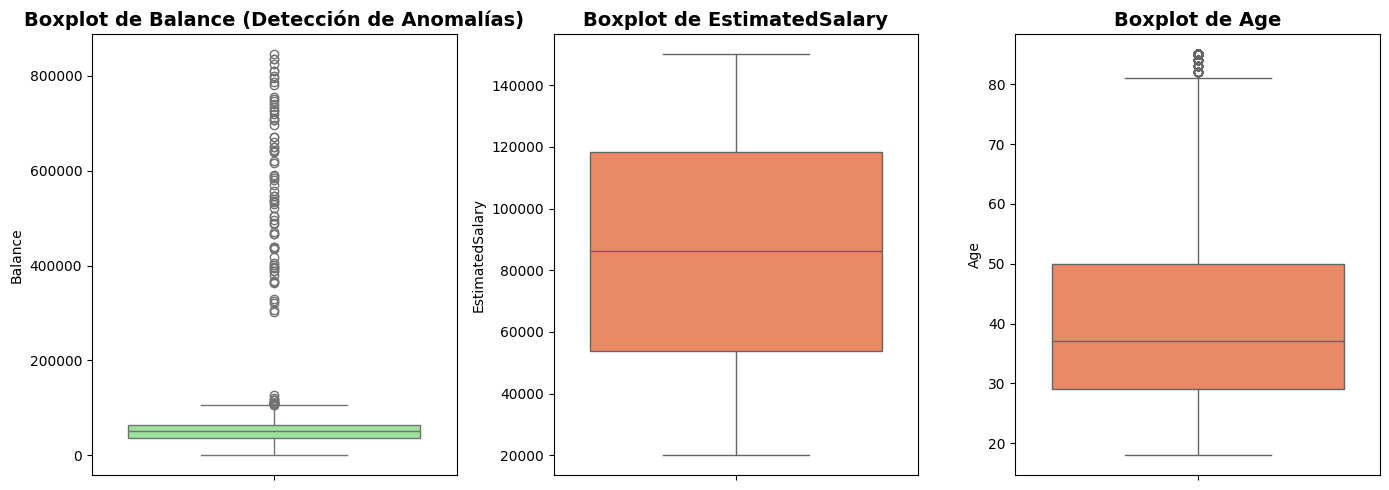

In [7]:
# 1. Generar Boxplots para Age, Balance y EstimatedSalary
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

sns.boxplot(y=data["Balance"], ax=axes[0], color="lightgreen")
axes[0].set_title("Boxplot de Balance (Detección de Anomalías)", fontsize=14, fontweight="bold")

sns.boxplot(y=data["EstimatedSalary"], ax=axes[1], color="coral")
axes[1].set_title("Boxplot de EstimatedSalary", fontsize=14, fontweight="bold")

sns.boxplot(y=data["Age"], ax=axes[2], color="coral")
axes[2].set_title("Boxplot de Age", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

In [8]:
# Detección para Age, Balance y EstimatedSalary
outliers_balance = diagnostico_outliers_iqr(data, "Balance")
outliers_salary = diagnostico_outliers_iqr(data, "EstimatedSalary")
outliers_age = diagnostico_outliers_iqr(data, "Age")

--- Análisis IQR para la variable 'Balance' ---
Q1: 36464.09 | Q3: 64413.36 | IQR: 27949.27
Límite Inferior: -5459.81 | Límite Superior: 106337.26
Registros fuera de límites: 89 (1.73%)

--- Análisis IQR para la variable 'EstimatedSalary' ---
Q1: 53718.63 | Q3: 118209.23 | IQR: 64490.60
Límite Inferior: -43017.27 | Límite Superior: 214945.14
Registros fuera de límites: 0 (0.00%)

--- Análisis IQR para la variable 'Age' ---
Q1: 29.00 | Q3: 50.00 | IQR: 21.00
Límite Inferior: -2.50 | Límite Superior: 81.50
Registros fuera de límites: 164 (3.18%)



## Inconsistencias

In [9]:
regla_tenure = (data["Tenure"] < 0) | (data["Tenure"] > 10)
regla_credit_score = (data["CreditScore"] < 300) | (data["CreditScore"] > 850)
regla_edad = (data["Age"] < 18) | (data["Age"] > 85)
regla_balance = (data["Balance"] < 0)
regla_products = (data["NumOfProducts"] < 1 ) | (data["NumOfProducts"] > 4)
regla_estimated_salary = (data["EstimatedSalary"] < 20000) | (data["EstimatedSalary"] > 150000)

In [10]:
# Detectar inconsistencias
inconsistentes = data[regla_tenure | regla_credit_score | regla_edad | regla_balance | regla_products | regla_estimated_salary]
print("Registros inconsistentes encontrados:")
display(inconsistentes)

Registros inconsistentes encontrados:


,CustomerID,Age,CreditScore,Tenure,Balance,NumOfProducts,EstimatedSalary,TotalAssets,Geography,churn


In [11]:
data.Geography.unique()

array(['Perú', 'Argentina', 'Chile'], dtype=object)

# Análisis exploratorio de datos

## Tipos de datos

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5150 entries, 0 to 5149
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       5150 non-null   object 
 1   Age              4891 non-null   float64
 2   CreditScore      5150 non-null   int64  
 3   Tenure           5150 non-null   int64  
 4   Balance          4530 non-null   float64
 5   NumOfProducts    5150 non-null   int64  
 6   EstimatedSalary  4741 non-null   float64
 7   TotalAssets      4530 non-null   float64
 8   Geography        5150 non-null   object 
 9   churn            5150 non-null   int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 402.5+ KB


## Medidas estadísticas variables continuas

In [13]:
data.drop(columns=["CustomerID", "churn"]).describe().round(3)

,Age,CreditScore,Tenure,Balance,NumOfProducts,EstimatedSalary,TotalAssets
count,4891.000,5150.000,5150.000,4530.000,5150.000,4741.000,4530.000
mean,41.204,577.036,4.488,58393.057,1.630,85686.994,61319.853
std,15.896,158.153,2.860,72160.454,0.751,37268.681,75758.196
min,18.000,300.000,0.000,0.000,1.000,20025.848,-1943.709
25%,29.000,441.000,2.000,36464.090,1.000,53718.632,38149.287
50%,37.000,576.000,4.000,50396.270,1.000,86157.202,52920.629
75%,50.000,715.000,7.000,64413.359,2.000,118209.234,67664.782
max,85.000,849.000,9.000,845587.562,4.000,149990.440,887217.416


## Medidas estadísticas variables discretas

In [14]:
data.drop(columns=["CustomerID"]).describe(include="object")

,Geography
count,5150
unique,3
top,Argentina
freq,1748


## Distribución de variables

In [15]:
# 1. Seleccionar subconjunto de variables numéricas continuas clave
numeric_cols = [
    "Age",
    "CreditScore",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary",
    "TotalAssets",
]

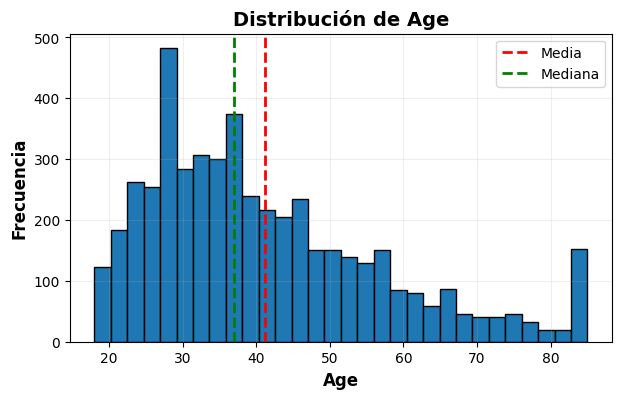

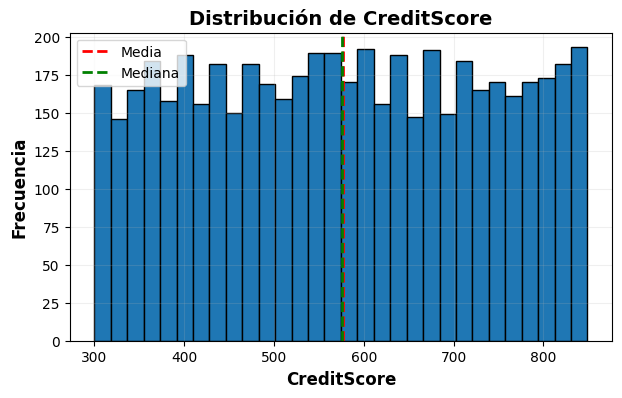

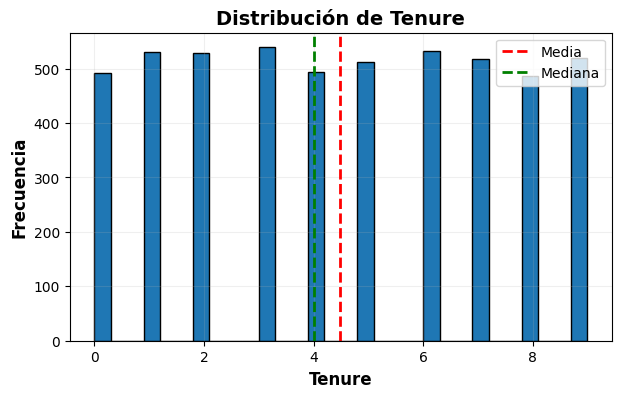

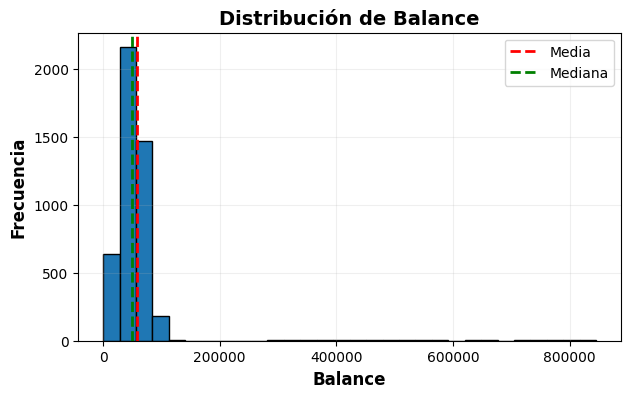

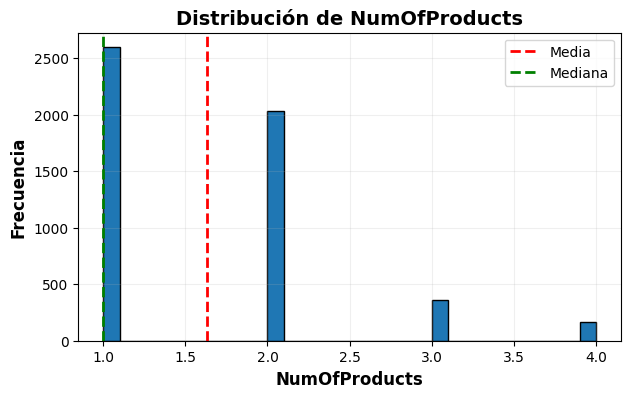

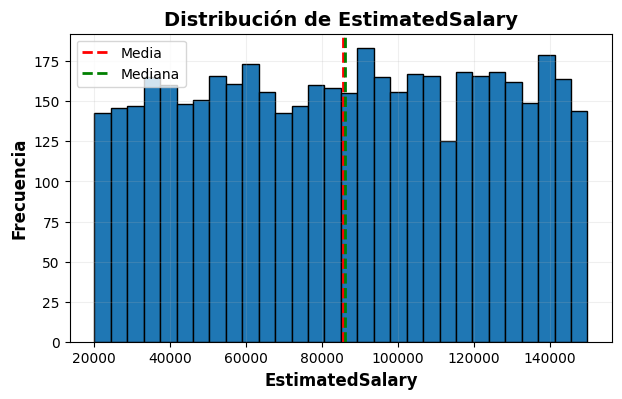

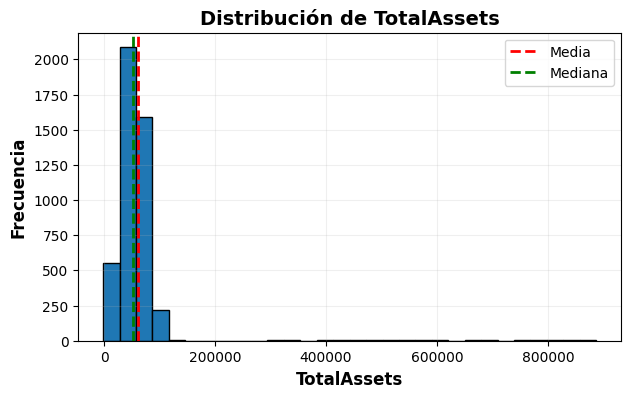

In [52]:
data_analisis = data.copy()
for variable in numeric_cols:

    plt.figure(figsize=(7, 4))

    plt.hist(data_analisis[variable].dropna(), bins=30, edgecolor="black")
    plt.axvline(data_analisis[variable].mean(), color="red", linestyle="dashed", linewidth=2, label="Media")
    plt.axvline(data_analisis[variable].median(), color="green", linestyle="dashed", linewidth=2, label="Mediana")

    # Agrega las etiquetas del label de media y mediana
    plt.legend()
    plt.title(f"Distribución de {variable}", fontsize=14, fontweight="bold")
    plt.xlabel(variable, fontsize=12, fontweight="bold")
    plt.ylabel("Frecuencia", fontsize=12, fontweight="bold")

    plt.grid(alpha=0.2)
    plt.show()

In [17]:
frecuencias_productos = data["NumOfProducts"].value_counts().sort_index()

display(frecuencias_productos)

,count
NumOfProducts,
1,2595
2,2032
3,359
4,164


In [20]:
porcentajes_productos = (
    data["NumOfProducts"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

display(porcentajes_productos.round(2))

,proportion
NumOfProducts,
1,50.39
2,39.46
3,6.97
4,3.18


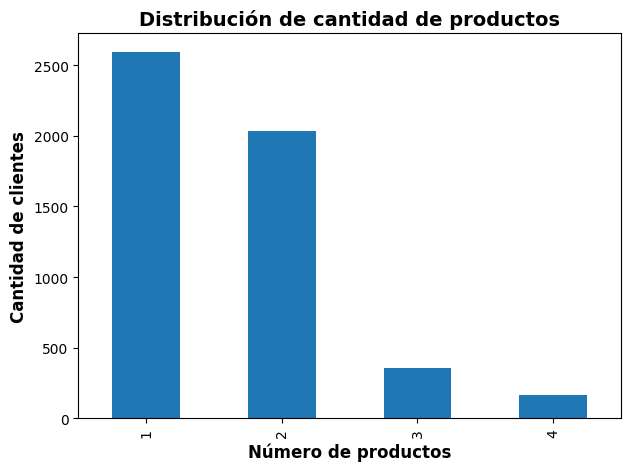

In [21]:
plt.figure(figsize=(7, 5))

data["NumOfProducts"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Distribución de cantidad de productos", fontsize=14, fontweight="bold")
plt.xlabel("Número de productos", fontsize=12, fontweight="bold")
plt.ylabel("Cantidad de clientes", fontsize=12, fontweight="bold")

plt.show()

## Análisis bivariado

In [22]:
def scatter_plot(data: pd.DataFrame, x: str, y: str):
  """
  Genera un gráfico de dispersión (scatter plot) para dos variables.

  Parámetros
  ----------
  data: pd.DataFrame
    Set de datos a analizar
  x: str
    Nombre de la variable en el eje X
  y: str
    Nombre de la variable en el eje Y

  Retorna
  -------
  None
  """
  plt.figure(figsize=(8, 5))

  plt.scatter(data[x], data[y], alpha=0.5)

  plt.xlabel(x, fontsize=14, fontweight="bold")
  plt.ylabel(y, fontsize=14, fontweight="bold")
  plt.title(f"{x} vs {y}", fontsize=16, fontweight="bold")

  plt.grid(alpha=0.2)

  plt.show()

### `Balance` versus `TotalAssets`

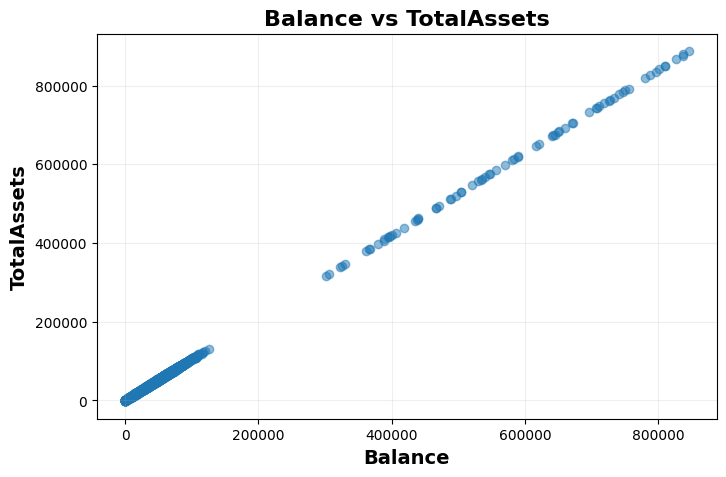

In [23]:
scatter_plot(
    data,
    "Balance",
    "TotalAssets"
)

### `Balance` versus `EstimatedSalary

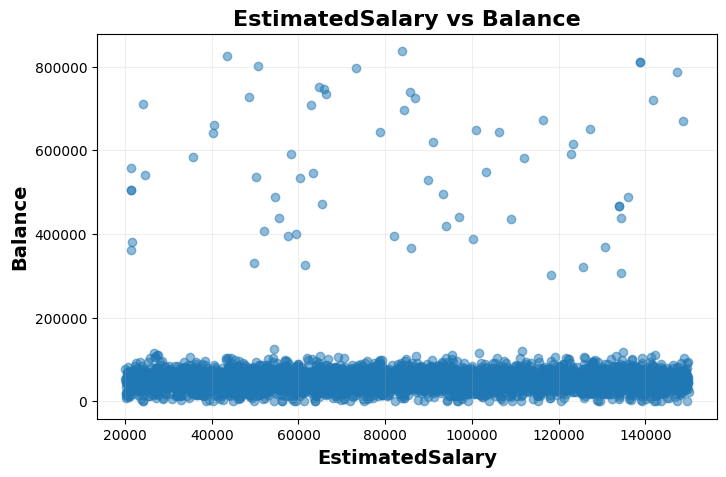

Correlación: -0.0064


In [30]:
scatter_plot(
    data,
    "EstimatedSalary",
    "Balance"
)
print(f"Correlación: {data['EstimatedSalary'].corr(data['Balance']):.4f}")

### `Balance` versus `Age`

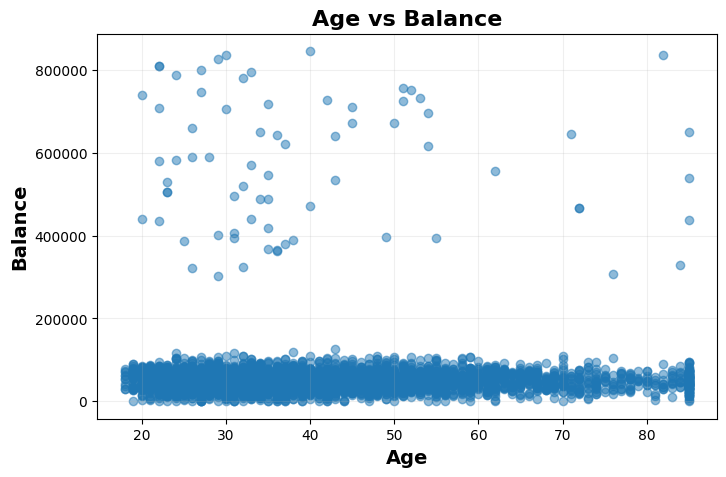

Correlación: -0.0128


In [31]:
scatter_plot(
    data,
    "Age",
    "Balance"
)

print(f"Correlación: {data['Age'].corr(data['Balance']):.4f}")

### `Balance` versus `CreditScore`

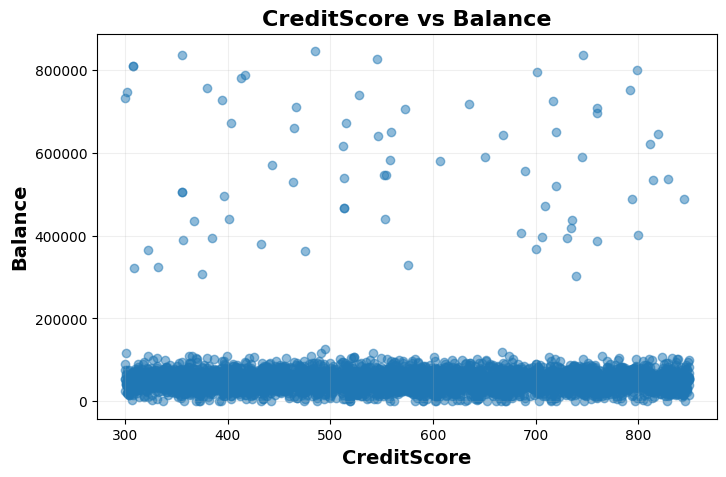

Correlación: -0.0113


In [32]:
scatter_plot(
    data,
    "CreditScore",
    "Balance"
)

print(f"Correlación: {data['CreditScore'].corr(data['Balance']):.4f}")

### `Balance` versus `Tenure`

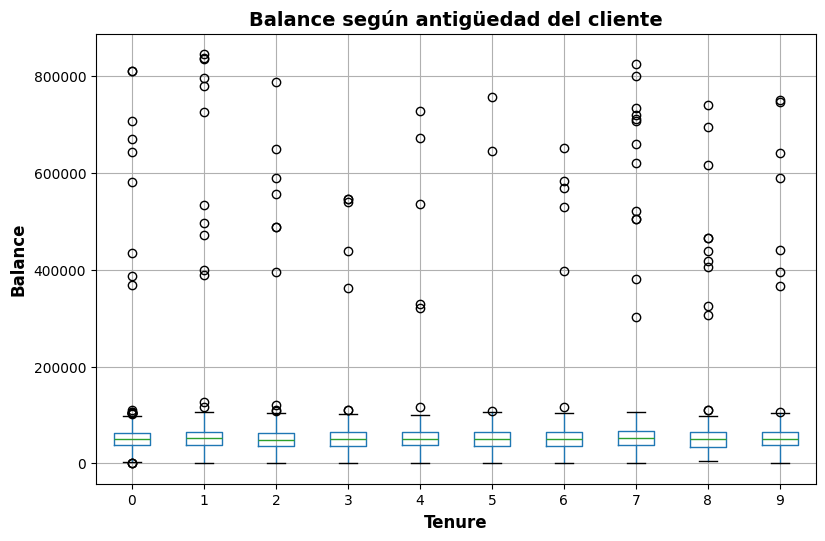

In [46]:
fig, ax = plt.subplots(figsize=(9, 6))

data.boxplot(column="Balance", by="Tenure", ax=ax)

ax.set_title("Balance según antigüedad del cliente", fontsize=14, fontweight="bold")
ax.set_xlabel("Tenure", fontsize=12, fontweight="bold")
ax.set_ylabel("Balance", fontsize=12, fontweight="bold")

fig.suptitle("")
plt.show()

In [47]:
resumen_tenure = (
    data.groupby("Tenure")["Balance"]
    .agg(["count", "mean", "median", "std"])
)

display(resumen_tenure.round(2))

,count,mean,median,std
Tenure,,,,
0,434,61118.10,50579.67,84382.74
1,467,65094.73,52619.50,96420.41
2,471,56260.68,48597.87,67418.78
3,465,54412.42,49373.39,50111.43
4,432,55468.68,50581.45,56622.76
5,465,52710.25,49946.48,47491.15
6,471,55014.19,50124.09,56024.79
7,451,66758.08,51746.19,99899.11
8,420,59876.63,50063.24,72991.43


### Análisis de `Balance` con atípicos

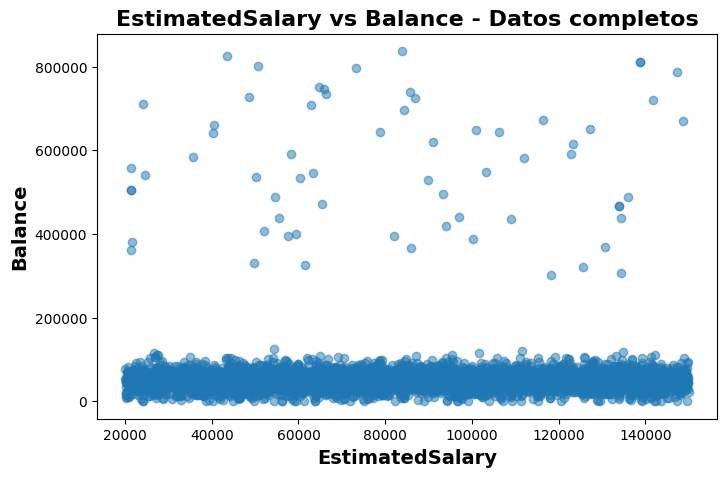

In [40]:
plt.figure(figsize=(8, 5))

plt.scatter(
    data["EstimatedSalary"],
    data["Balance"],
    alpha=0.5
)

plt.xlabel("EstimatedSalary", fontsize=14, fontweight="bold")
plt.ylabel("Balance", fontsize=14, fontweight="bold")
plt.title("EstimatedSalary vs Balance - Datos completos", fontsize=16, fontweight="bold")

plt.show()

### Análisis de `Balance` sin atípicos

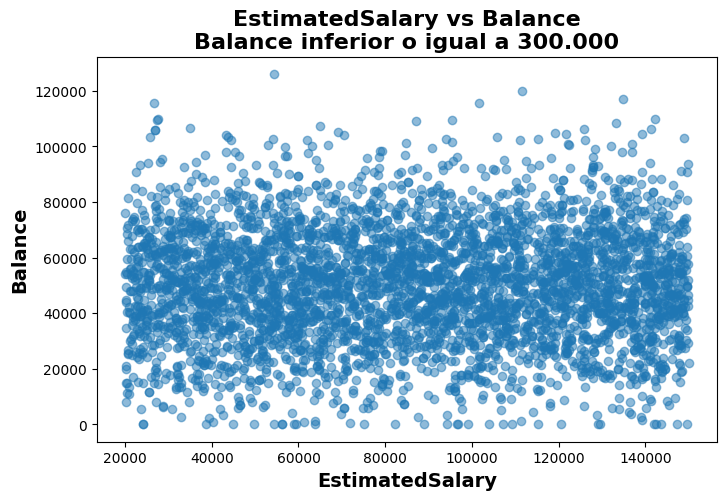

In [42]:
data_sin_extremos = data[data["Balance"] <= 300000]

plt.figure(figsize=(8, 5))

plt.scatter(
    data_sin_extremos["EstimatedSalary"],
    data_sin_extremos["Balance"],
    alpha=0.5
)

plt.xlabel("EstimatedSalary", fontsize=14, fontweight="bold")
plt.ylabel("Balance", fontsize=14, fontweight="bold")
plt.title("EstimatedSalary vs Balance\nBalance inferior o igual a 300.000", fontsize=16, fontweight="bold")

plt.show()

## Análisis de interdependencia (Multicolinealidad)

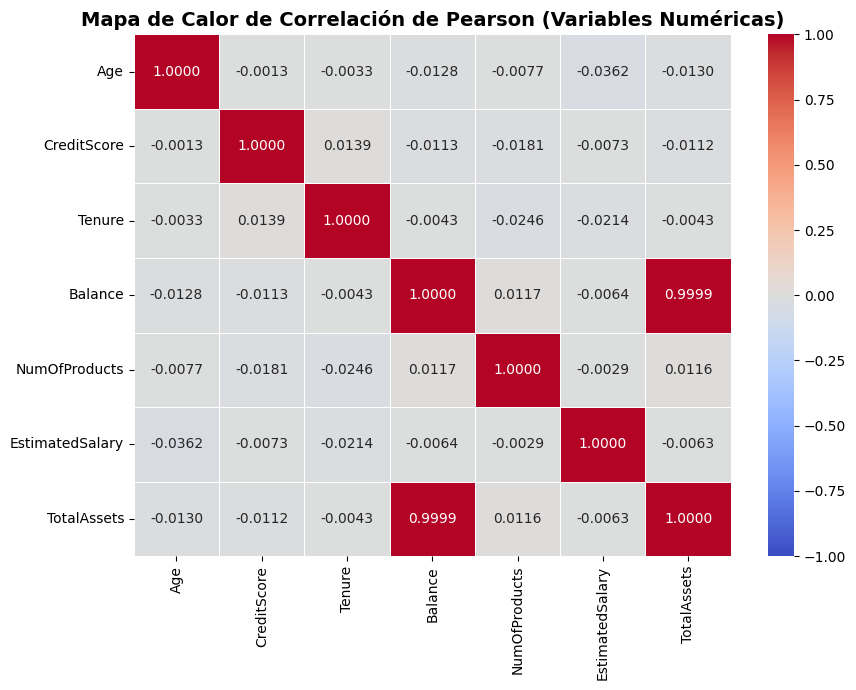

In [43]:
data_numeric = data[numeric_cols]

# 2. Calcular Coeficiente de Correlación de Pearson y dibujar Heatmap
correlation_matrix = data_numeric.corr(method="pearson")

plt.figure(figsize=(9, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".4f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title("Mapa de Calor de Correlación de Pearson (Variables Numéricas)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Definición de variables dependiente (`y`) e independientes (`X`)

In [ ]:
# Elimina ID, la variable redundante y la variable objetivo
X = data.drop(columns=["CustomerID", "TotalAssets", "churn"])
# Variable objetivo
y = data["churn"]

In [ ]:
# División en Train / Test ANTES de cualquier transformación (Paso clave contra Data Leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=29, stratify=y
)

print(f"Dataset de Entrenamiento (X_train): {X_train.shape}")
print(f"Dataset de Prueba (X_test): {X_test.shape}\n")

Dataset de Entrenamiento (X_train): (4120, 7)
Dataset de Prueba (X_test): (1030, 7)



# Definición de Sub-Pipelines por Tipo de Variable

In [ ]:
# A. Variables numéricas normales (sin presencia severa de outliers)
num_standard_features = ["Age", "CreditScore", "Tenure", "EstimatedSalary"]
num_standard_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),  # Imputación por media
        ("scaler", StandardScaler()),  # Escalado estándar (Z-score)
    ]
)

# B. Variables numéricas con presencia de Outliers severos (como Balance)
num_robust_features = ["Balance"]
num_robust_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "scaler", RobustScaler(),
        ),  # Escalador basado en Mediana e IQR (resistente a outliers)
    ]
)

# C. Variables categóricas
categorical_features = ["Geography"]
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),  # Imputación por moda
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
        ),
    ]
)

# Integración con ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num_std", num_standard_pipeline, num_standard_features),
        ("num_robust", num_robust_pipeline, num_robust_features),
        ("cat", categorical_pipeline, categorical_features),
    ],
    remainder="passthrough",  # Mantiene sin modificar variables numéricas discretas como NumOfProducts
)

In [ ]:
preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('num_std',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'CreditScore', 'Tenure',
                                  'EstimatedSalary']),
                                ('num_robust',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', RobustScaler())]),
                                 ['Balance']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Geography'])])

# Ajuste y Transformación de Datos (Zero Data Leakage)

In [ ]:
# Fit y Transform SOLO sobre el conjunto de Entrenamiento
X_train_processed = preprocessor.fit_transform(X_train)

# Transform (NUNCA FIT) sobre el conjunto de Prueba
X_test_processed = preprocessor.transform(X_test)

# Obtener nombres de columnas procesadas para inspección
encoded_cat_cols = (
    preprocessor.named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_features)
)

all_feature_names = (
    num_standard_features
    + num_robust_features
    + list(encoded_cat_cols)
    + ["NumOfProducts"]
)

In [ ]:
all_feature_names

['Age',
 'CreditScore',
 'Tenure',
 'EstimatedSalary',
 'Balance',
 'Geography_Argentina',
 'Geography_Chile',
 'Geography_Perú',
 'NumOfProducts']

In [ ]:
X_train_processed.shape

(4120, 9)

In [ ]:
# Convertir de nuevo a DataFrame para verificación
X_train_prep = pd.DataFrame(X_train_processed, columns=all_feature_names)

X_train_prep.head(3)

,Age,CreditScore,Tenure,EstimatedSalary,Balance,Geography_Argentina,Geography_Chile,Geography_Perú,NumOfProducts
0,0.574257,-1.334332,-0.527896,-0.210579,-0.804353,0.0,0.0,1.0,2.0
1,-0.137181,-0.556984,1.222129,1.233869,-1.303449,0.0,0.0,1.0,2.0
2,1.673751,-1.542889,-1.227905,0.000000,0.833158,0.0,0.0,1.0,2.0


**Importante**

Este es el conjunto de datos con el cual será `entrenado` el modelo.